In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

### Data Processing

In [21]:
# Read in initial data files
df_energy = pd.read_csv('data/raw/energy_dataset.csv')
df_weather = pd.read_csv('data/raw/weather_features.csv')

# Convert date/time to datetime format
df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True)
df_weather['dt_iso'] = pd.to_datetime(df_weather['dt_iso'], utc=True)

# Extract date and hour for each dataframe
df_energy.insert(1, 'date', df_energy['time'].dt.date)
df_energy.insert(2, 'hour', df_energy['time'].dt.hour)

df_weather.insert(1, 'date', df_weather['dt_iso'].dt.date)
df_weather.insert(2, 'hour', df_weather['dt_iso'].dt.hour)

# Rename weather column
df_weather = df_weather.rename(columns={'dt_iso': 'time'})

In [22]:
df_energy.shape

(35064, 31)

In [23]:
# Print information on weather dataset
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   time                 178396 non-null  datetime64[us, UTC]
 1   date                 178396 non-null  object             
 2   hour                 178396 non-null  int32              
 3   city_name            178396 non-null  str                
 4   temp                 178396 non-null  float64            
 5   temp_min             178396 non-null  float64            
 6   temp_max             178396 non-null  float64            
 7   pressure             178396 non-null  int64              
 8   humidity             178396 non-null  int64              
 9   wind_speed           178396 non-null  int64              
 10  wind_deg             178396 non-null  int64              
 11  rain_1h              178396 non-null  float64            
 12  rain_3h      

In [24]:
# Drop columns with string descriptions of weather and weather ID. Model will only take in numerical input as features
df_weather = df_weather.drop(columns=['weather_id', 'weather_main', 'weather_description', 'weather_icon'])

# Eliminate any leading or trailing spaces for city name strings
df_weather['city_name'] = df_weather['city_name'].str.strip()

In [25]:
# Identify any duplicated data
dup_rows = df_weather[df_weather.duplicated(keep=False)]
dup_rows

# Drop duplicate rows for cities since numerical values are the same
df_weather_clean = df_weather.drop_duplicates(keep='first').reset_index(drop=True)
df_weather_clean

# Print the number of rows of data per city
print(f'Data Rows per City:')
print(df_weather_clean.groupby('city_name').size())
print(f'\nData Rows in Energy df: {df_energy.shape[0]}')

Data Rows per City:
city_name
Barcelona    35064
Bilbao       35064
Madrid       35064
Seville      35064
Valencia     35064
dtype: int64

Data Rows in Energy df: 35064


In [26]:
# Determine how many null values are in the dataframe
df_weather.isnull().sum()

time          0
date          0
hour          0
city_name     0
temp          0
temp_min      0
temp_max      0
pressure      0
humidity      0
wind_speed    0
wind_deg      0
rain_1h       0
rain_3h       0
snow_3h       0
clouds_all    0
dtype: int64

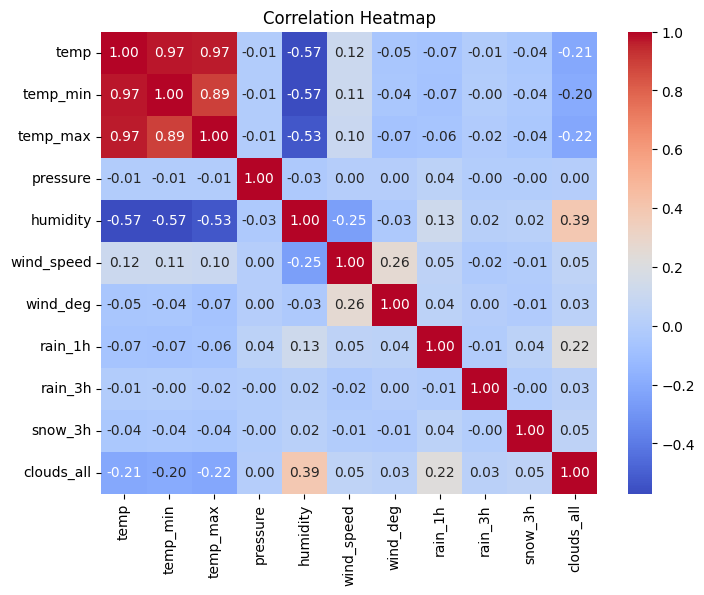

In [27]:
# Perform a correlation analysis across remaining features to drop any features that are highly correlated
df_corr = df_weather_clean.drop(columns=['time', 'date', 'hour', 'city_name'])
corr = df_corr.corr(method='pearson')

# Plot the correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [28]:
# Select upper triangle of correlation matrix
upper = corr.abs().where(
    np.triu(np.ones(corr.abs().shape), k=1).astype(bool)
)

# Find columns with correlation > 0.75
to_drop = [column for column in upper.columns if any(upper[column] > 0.75)]

print('Columns to drop:')
print(to_drop)

# Drop highly correlated columns
df_weather_filter = df_weather_clean.drop(columns=to_drop)

# Convert temperature (K) to Celsius
df_weather_filter['temp'] = df_weather_filter['temp'] - 273.15

Columns to drop:
['temp_min', 'temp_max']


In [29]:
df_weather_filter

,time,date,hour,city_name,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,2014-12-31,23,Valencia,-2.675,1001,77,1,62,0.0,0.0,0.0,0
1,2015-01-01 00:00:00+00:00,2015-01-01,0,Valencia,-2.675,1001,77,1,62,0.0,0.0,0.0,0
2,2015-01-01 01:00:00+00:00,2015-01-01,1,Valencia,-3.464,1002,78,0,23,0.0,0.0,0.0,0
3,2015-01-01 02:00:00+00:00,2015-01-01,2,Valencia,-3.464,1002,78,0,23,0.0,0.0,0.0,0
4,2015-01-01 03:00:00+00:00,2015-01-01,3,Valencia,-3.464,1002,78,0,23,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175315,2018-12-31 18:00:00+00:00,2018-12-31,18,Seville,14.610,1028,54,3,30,0.0,0.0,0.0,0
175316,2018-12-31 19:00:00+00:00,2018-12-31,19,Seville,12.610,1029,62,3,30,0.0,0.0,0.0,0
175317,2018-12-31 20:00:00+00:00,2018-12-31,20,Seville,12.000,1028,58,4,50,0.0,0.0,0.0,0
175318,2018-12-31 21:00:00+00:00,2018-12-31,21,Seville,11.000,1029,57,4,60,0.0,0.0,0.0,0


In [30]:
df_weather_filter.describe().round(2)

,hour,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
count,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00
mean,11.50,16.56,1070.20,68.03,2.47,166.72,0.07,0.00,0.00,24.34
std,6.92,8.02,6021.77,21.84,2.10,116.55,0.39,0.01,0.22,30.34
min,0.00,-10.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.75,10.68,1013.00,53.00,1.00,56.00,0.00,0.00,0.00,0.00
50%,11.50,16.00,1018.00,72.00,2.00,178.00,0.00,0.00,0.00,16.00
75%,17.25,22.09,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00
max,23.00,42.45,1008371.00,100.00,133.00,360.00,12.00,2.32,21.50,100.00


,time,date,hour,temp_Barcelona,temp_Bilbao,temp_Madrid,temp_Seville,temp_Valencia,pressure_Barcelona,pressure_Bilbao,...,snow_3h_Barcelona,snow_3h_Bilbao,snow_3h_Madrid,snow_3h_Seville,snow_3h_Valencia,clouds_all_Barcelona,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Seville,clouds_all_Valencia
0,2014-12-31 23:00:00+00:00,2014-12-31,23,8.475,-3.492687,-5.825,0.225,-2.675,1035,1036,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
1,2015-01-01 00:00:00+00:00,2015-01-01,0,8.475,-3.386500,-5.825,0.225,-2.675,1035,1035,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
2,2015-01-01 01:00:00+00:00,2015-01-01,1,8.136,-3.898312,-6.964,0.936,-3.464,1036,1036,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
3,2015-01-01 02:00:00+00:00,2015-01-01,2,8.136,-3.946656,-6.964,0.936,-3.464,1036,1035,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
4,2015-01-01 03:00:00+00:00,2015-01-01,3,8.136,-3.664500,-6.964,0.936,-3.464,1036,1035,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 18:00:00+00:00,2018-12-31,18,10.980,8.110000,10.410,14.610,12.490,1027,1033,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
35060,2018-12-31 19:00:00+00:00,2018-12-31,19,9.490,6.660000,6.970,12.610,9.990,1027,1034,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
35061,2018-12-31 20:00:00+00:00,2018-12-31,20,8.990,4.000000,5.000,12.000,8.510,1028,1034,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
35062,2018-12-31 21:00:00+00:00,2018-12-31,21,7.980,3.450000,3.420,11.000,6.990,1028,1034,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0


,hour,temp_Barcelona,temp_Bilbao,temp_Madrid,temp_Seville,temp_Valencia,pressure_Barcelona,pressure_Bilbao,pressure_Madrid,pressure_Seville,...,snow_3h_Barcelona,snow_3h_Bilbao,snow_3h_Madrid,snow_3h_Seville,snow_3h_Valencia,clouds_all_Barcelona,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Seville,clouds_all_Valencia
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,...,35064.0,35064.00,35064.00,35064.0,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00
mean,11.50,16.72,13.29,15.13,20.02,17.63,1287.21,1017.48,1011.78,1018.54,...,0.0,0.02,0.00,0.0,0.00,22.71,43.44,20.66,14.17,20.74
std,6.92,6.72,6.80,9.33,8.08,7.23,13463.03,9.82,20.24,6.87,...,0.0,0.50,0.01,0.0,0.01,27.33,33.74,29.66,26.17,25.60
min,0.00,-10.91,-6.30,-9.02,-2.10,-4.32,0.00,961.00,927.00,986.00,...,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.75,11.56,8.30,8.00,14.18,12.00,1014.00,1013.00,1013.00,1014.00,...,0.0,0.00,0.00,0.0,0.00,0.00,6.00,0.00,0.00,0.00
50%,11.50,16.26,13.02,13.78,19.29,17.04,1017.00,1019.00,1017.00,1018.00,...,0.0,0.00,0.00,0.0,0.00,20.00,40.00,0.00,0.00,20.00
75%,17.25,22.00,17.89,21.80,25.73,23.00,1021.00,1024.00,1022.00,1023.00,...,0.0,0.00,0.00,0.0,0.00,36.00,75.00,40.00,20.00,20.00
max,23.00,36.00,39.32,40.18,42.45,38.00,1008371.00,1042.00,1042.00,1090.00,...,0.0,21.50,1.05,0.0,1.12,100.00,100.00,100.00,100.00,100.00


### Data Exploration

In [31]:
df_weather_filter.dtypes

time          datetime64[us, UTC]
date                       object
hour                        int32
city_name                     str
temp                      float64
pressure                    int64
humidity                    int64
wind_speed                  int64
wind_deg                    int64
rain_1h                   float64
rain_3h                   float64
snow_3h                   float64
clouds_all                  int64
dtype: object

In [32]:
# Define a function to plot the data distribution as a histogram
def data_hist(df, max_bins=50):
    # Select numeric columns only, excluding non-numeric columns
    feat_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    if 'hour' in feat_cols:
        feat_cols.remove('hour')
    
    # Determine the number of rows and columns for subplots
    n_cols = 3  # you can adjust this
    n_rows = int(np.ceil(len(feat_cols) / n_cols))
    
    # Create subplots
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axs = axs.flatten()  # flatten in case of multiple rows
    
    # Plot each numeric column
    for i, col in enumerate(feat_cols):

        # Determine the min and max values of the data column
        col_min = df[col].min()
        col_max = df[col].max()
        col_range = col_max - col_min

        # Determine the number of bins
        # For integer data, cap at maximum number of bins specified as function input
        if pd.api.types.is_integer_dtype(df[col]):
            bins = min(col_range+1, max_bins)
        # For float data, dynamically determine bin numbers based on data range
        else:
            step = col_range / 20 if col_range > 0 else 1
            bins = math.ceil(col_range / step)
            bins = min(bins, max_bins)

        # Plot the histogram    
        sns.histplot(df[col], bins=bins, kde=True, ax=axs[i])

        # Set the title based on the column name
        axs[i].set_title(col)
    
    # Remove any unused subplots
    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])
    
    plt.tight_layout()
    plt.show()

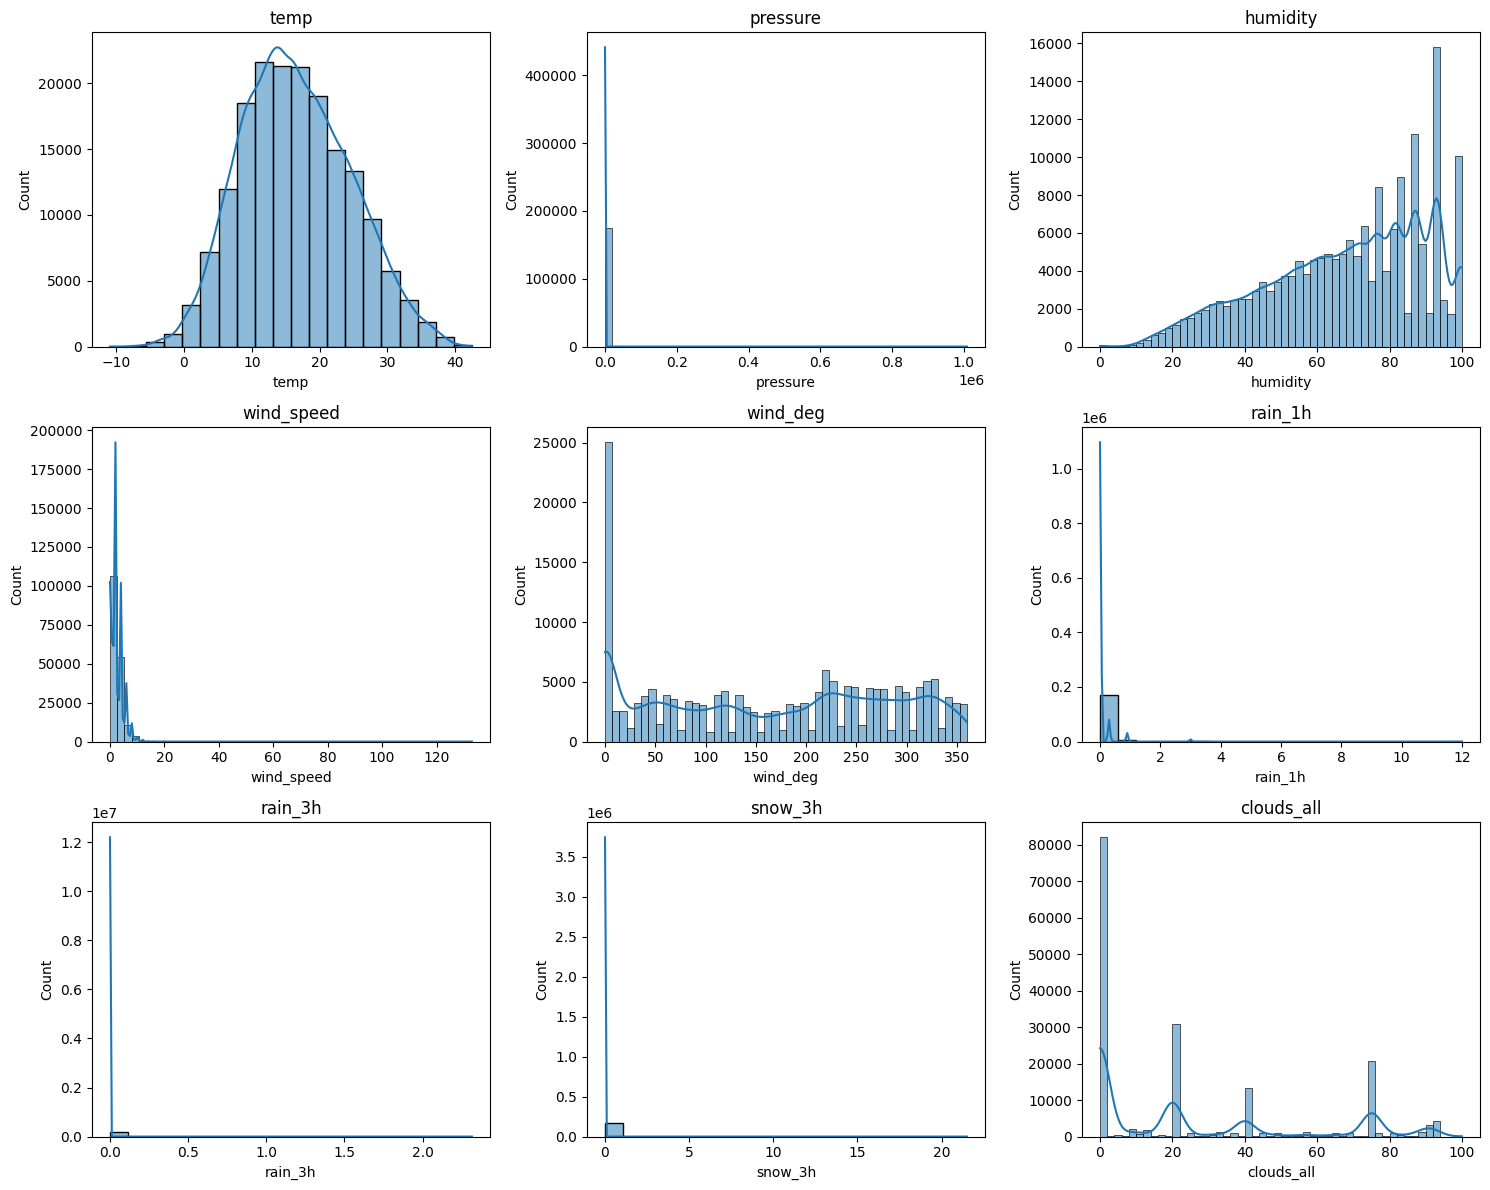

In [33]:
# Plot weather data as histogram
data_hist(df_weather_filter)

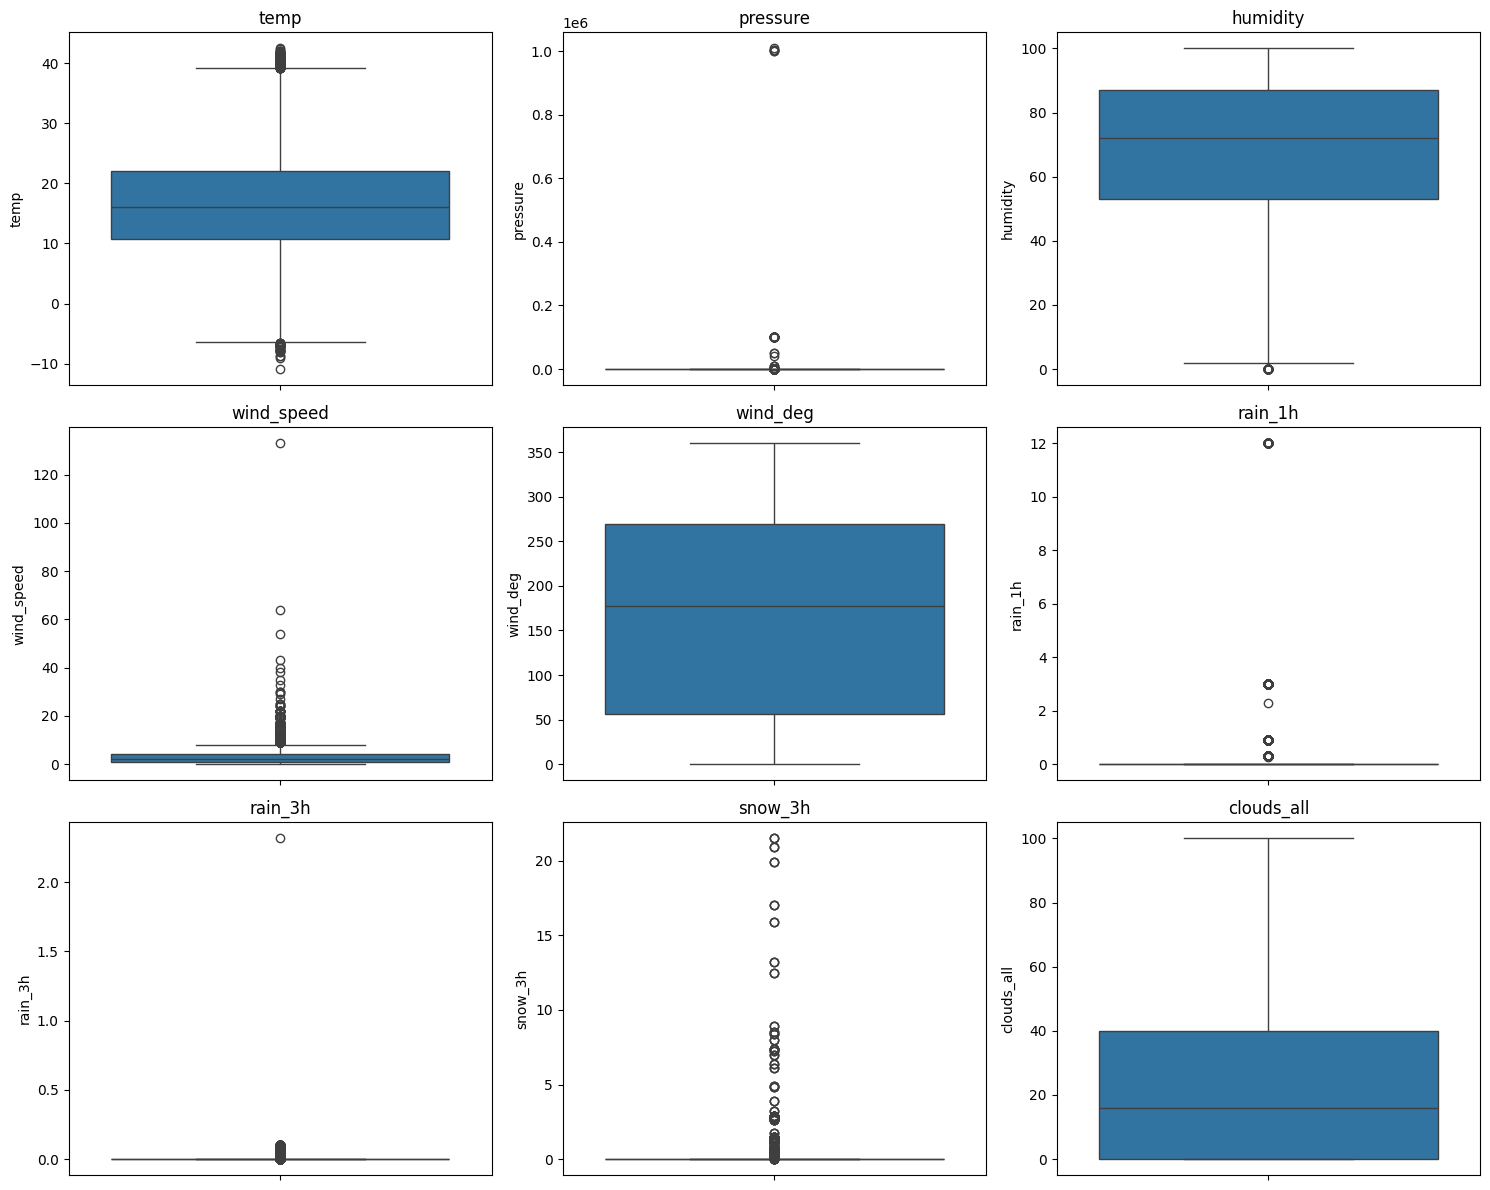

In [34]:
# Plot boxplots of the weather data to determine outliers
numeric_cols = df_weather_filter.select_dtypes(include=['float64', 'int64']).columns

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df_weather_filter[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [39]:
# Remove outliers for pressure (max pressure = 1045 hPa, min pressure = 950 hPa); set to NaN
# Source: https://en.wikipedia.org/wiki/List_of_atmospheric_pressure_records_in_Europe?utm_source=copilot.com
df_weather_filter.loc[
    (df_weather_filter['pressure'] > 1045) |
    (df_weather_filter['pressure'] < 950),
    'pressure'
] = np.nan

# Remove outliers for wind speed (max wind > 13 m/s); set to NaN
# Source: https://www.meteoblue.com/en/weather/historyclimate/climatemodelled/spain_spain_2510769 
df_weather_filter.loc[
    df_weather_filter['wind_speed'] > 40,
    'wind_speed'
] = np.nan

# Print the number of NaN values across the columns
df_weather_filter.isnull().sum()

time             0
date             0
hour             0
city_name        0
temp             0
pressure      1106
humidity         0
wind_speed       8
wind_deg         0
rain_1h          0
rain_3h          0
snow_3h          0
clouds_all       0
dtype: int64

In [42]:
# Create a copy of filtered weather dataframe
df_weather_intp = df_weather_filter.copy()

# Interpolate pressure data across cities
df_weather_intp['pressure'] = (
    df_weather_intp
    .groupby('city_name')['pressure']
    .transform(lambda x: x.interpolate())
)

# Interpolate wind speed data across cities
df_weather_intp['wind_speed'] = (
    df_weather_intp
    .groupby('city_name')['wind_speed']
    .transform(lambda x: x.interpolate())
)

# Confirm that interpolation works and that there are no null values
df_weather_intp.isnull().sum()

time          0
date          0
hour          0
city_name     0
temp          0
pressure      0
humidity      0
wind_speed    0
wind_deg      0
rain_1h       0
rain_3h       0
snow_3h       0
clouds_all    0
dtype: int64

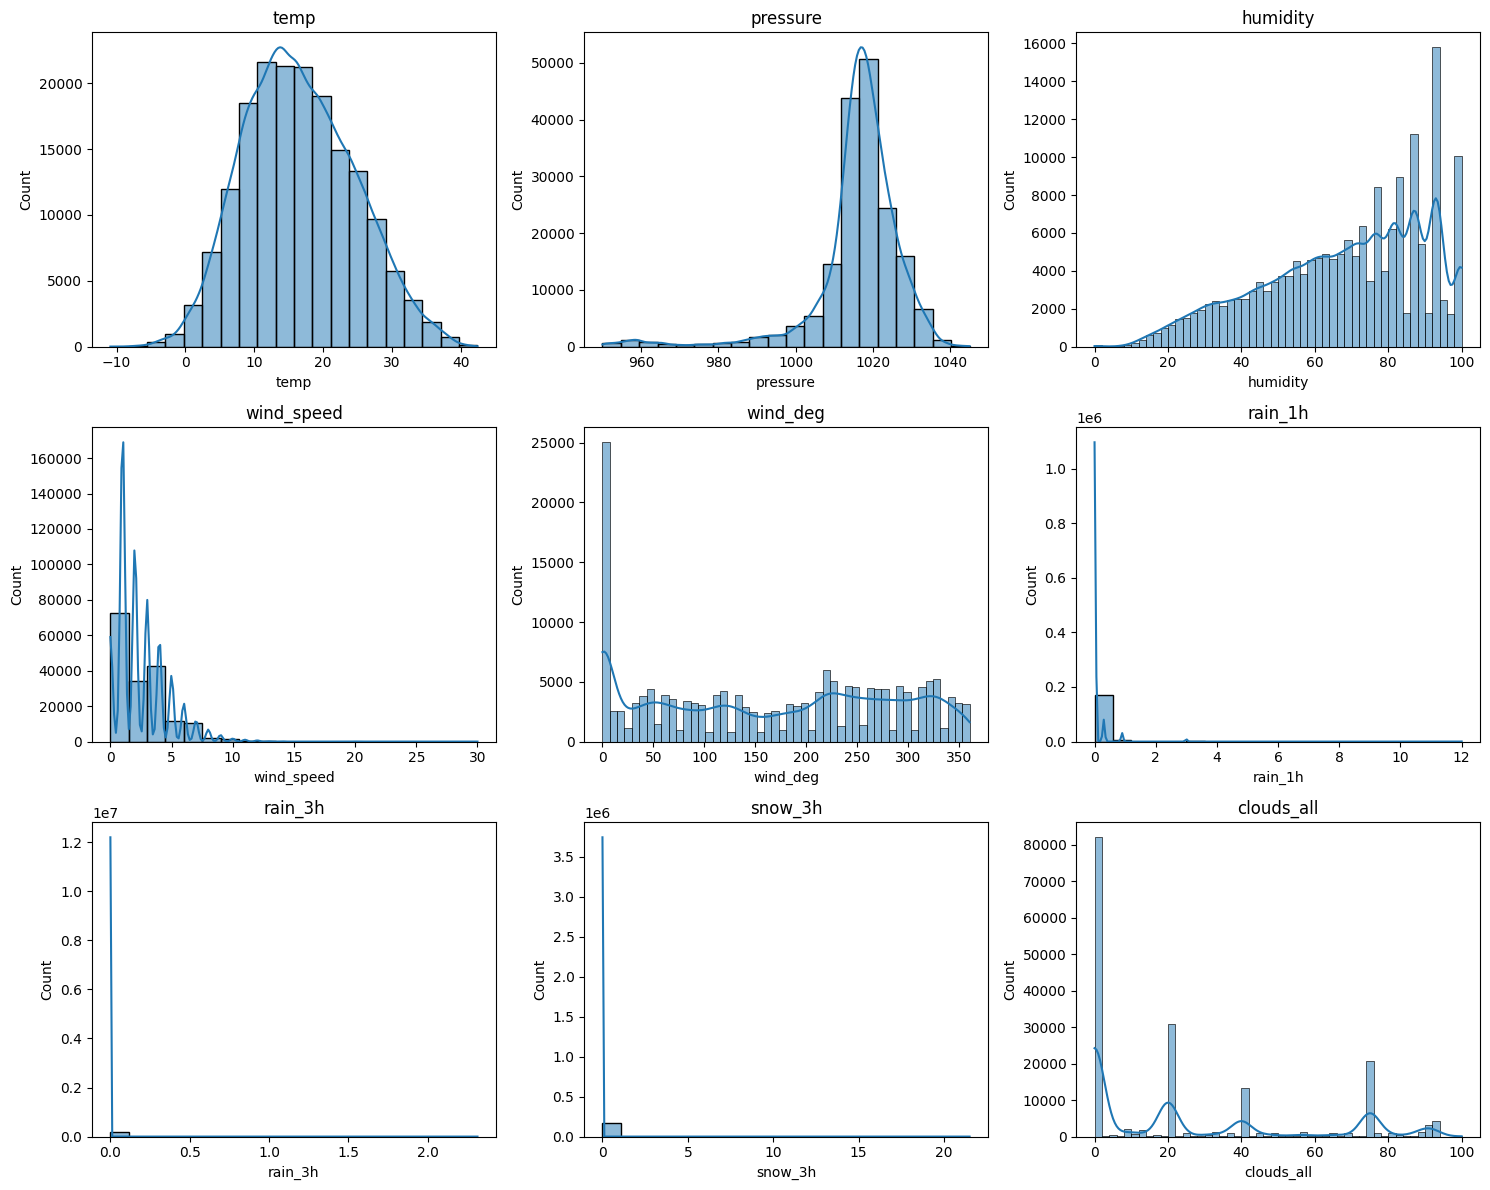

In [43]:
data_hist(df_weather_intp)

In [80]:
df_weather_filter

,time,date,hour,city_name,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,2014-12-31,23.0,Valencia,-2.675,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
1,2015-01-01 00:00:00+00:00,2015-01-01,0.0,Valencia,-2.675,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2,2015-01-01 01:00:00+00:00,2015-01-01,1.0,Valencia,-3.464,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
3,2015-01-01 02:00:00+00:00,2015-01-01,2.0,Valencia,-3.464,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
4,2015-01-01 03:00:00+00:00,2015-01-01,3.0,Valencia,-3.464,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175315,2018-12-31 18:00:00+00:00,2018-12-31,18.0,Seville,14.610,1028.0,54.0,3.0,30.0,0.0,0.0,0.0,0.0
175316,2018-12-31 19:00:00+00:00,2018-12-31,19.0,Seville,12.610,1029.0,62.0,3.0,30.0,0.0,0.0,0.0,0.0
175317,2018-12-31 20:00:00+00:00,2018-12-31,20.0,Seville,12.000,1028.0,58.0,4.0,50.0,0.0,0.0,0.0,0.0
175318,2018-12-31 21:00:00+00:00,2018-12-31,21.0,Seville,11.000,1029.0,57.0,4.0,60.0,0.0,0.0,0.0,0.0


In [ ]:
# Pivot the filtered and interpolated weather table to wide format (i.e. temp_Valencia, temp_Bilbao, temp_Seville, etc.)

# Keep the temporal id columns
id_cols = ['time', 'date', 'hour']

# Pivot the dataframe
df_weather_wide = df_weather_intp.pivot(
    index=id_cols,
    columns='city_name'
)

# Flatten multi-level column names
df_weather_wide.columns = [
    f"{feature}_{city}"
    for feature, city in df_weather_wide.columns
]

# Change index columns back to normal columns
df_weather_wide = df_weather_wide.reset_index()

In [47]:
df_weather_wide

,time,date,hour,temp_Barcelona,temp_Bilbao,temp_Madrid,temp_Seville,temp_Valencia,pressure_Barcelona,pressure_Bilbao,...,snow_3h_Barcelona,snow_3h_Bilbao,snow_3h_Madrid,snow_3h_Seville,snow_3h_Valencia,clouds_all_Barcelona,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Seville,clouds_all_Valencia
0,2014-12-31 23:00:00+00:00,2014-12-31,23,8.475,-3.492687,-5.825,0.225,-2.675,1035.0,1036.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
1,2015-01-01 00:00:00+00:00,2015-01-01,0,8.475,-3.386500,-5.825,0.225,-2.675,1035.0,1035.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
2,2015-01-01 01:00:00+00:00,2015-01-01,1,8.136,-3.898312,-6.964,0.936,-3.464,1036.0,1036.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
3,2015-01-01 02:00:00+00:00,2015-01-01,2,8.136,-3.946656,-6.964,0.936,-3.464,1036.0,1035.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
4,2015-01-01 03:00:00+00:00,2015-01-01,3,8.136,-3.664500,-6.964,0.936,-3.464,1036.0,1035.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 18:00:00+00:00,2018-12-31,18,10.980,8.110000,10.410,14.610,12.490,1027.0,1033.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
35060,2018-12-31 19:00:00+00:00,2018-12-31,19,9.490,6.660000,6.970,12.610,9.990,1027.0,1034.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
35061,2018-12-31 20:00:00+00:00,2018-12-31,20,8.990,4.000000,5.000,12.000,8.510,1028.0,1034.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
35062,2018-12-31 21:00:00+00:00,2018-12-31,21,7.980,3.450000,3.420,11.000,6.990,1028.0,1034.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0


In [48]:
df_weather_wide.describe().round(2)

,hour,temp_Barcelona,temp_Bilbao,temp_Madrid,temp_Seville,temp_Valencia,pressure_Barcelona,pressure_Bilbao,pressure_Madrid,pressure_Seville,...,snow_3h_Barcelona,snow_3h_Bilbao,snow_3h_Madrid,snow_3h_Seville,snow_3h_Valencia,clouds_all_Barcelona,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Seville,clouds_all_Valencia
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,...,35064.0,35064.00,35064.00,35064.0,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00
mean,11.50,16.72,13.29,15.13,20.02,17.63,1017.32,1017.48,1012.39,1018.53,...,0.0,0.02,0.00,0.0,0.00,22.71,43.44,20.66,14.17,20.74
std,6.92,6.72,6.80,9.33,8.08,7.23,7.40,9.82,18.68,6.85,...,0.0,0.50,0.01,0.0,0.01,27.33,33.74,29.66,26.17,25.60
min,0.00,-10.91,-6.30,-9.02,-2.10,-4.32,977.00,961.00,950.00,986.00,...,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.75,11.56,8.30,8.00,14.18,12.00,1014.00,1013.00,1013.00,1014.00,...,0.0,0.00,0.00,0.0,0.00,0.00,6.00,0.00,0.00,0.00
50%,11.50,16.26,13.02,13.78,19.29,17.04,1017.00,1019.00,1017.00,1018.00,...,0.0,0.00,0.00,0.0,0.00,20.00,40.00,0.00,0.00,20.00
75%,17.25,22.00,17.89,21.80,25.73,23.00,1021.00,1024.00,1022.00,1023.00,...,0.0,0.00,0.00,0.0,0.00,36.00,75.00,40.00,20.00,20.00
max,23.00,36.00,39.32,40.18,42.45,38.00,1039.00,1042.00,1042.00,1045.00,...,0.0,21.50,1.05,0.0,1.12,100.00,100.00,100.00,100.00,100.00


In [49]:
# Write the cleaned dataframes to csv files
df_weather_intp.to_csv('data/processed/weather_long.csv', index=False)
df_weather_wide.to_csv('data/processed/weather_wide.csv', index=False)